In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\krish patil\Downloads\data clean powe\python project\surat_uncleaned.csv")

df.tail()

,property_name,areaWithType,square_feet,transaction,status,floor,furnishing,facing,description,price_per_sqft,price
4520,6 BHK Apartment for Sale in Millionaires Lifes...,Carpet Area,2000 sqft,New Property,Poss. by Dec '26,5 out of 12,Unfurnished,South - East,"Check out Millionaires Lifestyle in Vesu, one ...",NaN,Call for Price
4521,"4 BHK Apartment for Sale in Savan Superia, Alt...",Super Area,3600 sqft,New Property,Poss. by Dec '25,5 out of 16,Unfurnished,South - East,Superia is a premium residential project launc...,NaN,Call for Price
4522,5 BHK Apartment for Sale in Roongta Green Vall...,Carpet Area,2250 sqft,New Property,Poss. by Dec '25,7 out of 13,Unfurnished,North - East,"When it comes to beautiful homes, nothing beat...",NaN,Call for Price
4523,"6 BHK Apartment for Sale in Cellestial Dreams,...",Carpet Area,3450 sqft,New Property,Ready to Move,7 out of 18,Unfurnished,North - West,"DRB Ravani Cellestial Dreams in Vesu, Surat is...",NaN,Call for Price
4524,4 BHK Apartment for Sale in Roongta Green Vall...,Super Area,4500 sqft,New Property,Ready to Move,3 out of 12,Unfurnished,North,Roongta Green Valley is one of the popular res...,NaN,Call for Price


In [2]:
# Dataset shape
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

# Column names
print("\nColumn Names:")
print(df.columns.tolist())

# Data types
print("\nData Types:")
print(df.dtypes)

# First 5 records
print("\nFirst 5 Records:")
display(df.head())

Rows: 4525
Columns: 11

Column Names:
['property_name', 'areaWithType', 'square_feet', 'transaction', 'status', 'floor', 'furnishing', 'facing', 'description', 'price_per_sqft', 'price']

Data Types:
property_name     object
areaWithType      object
square_feet       object
transaction       object
status            object
floor             object
furnishing        object
facing            object
description       object
price_per_sqft    object
price             object
dtype: object

First 5 Records:


,property_name,areaWithType,square_feet,transaction,status,floor,furnishing,facing,description,price_per_sqft,price
0,2 BHK Apartment for Sale in Dindoli Surat,Carpet Area,644 sqft,New Property,Poss. by Oct '24,5 out of 10,Unfurnished,West,"Luxury project with basement parking, Solar ro...","₹2,891 per sqft",₹33.8 Lac
1,2 BHK Apartment for Sale in Althan Surat,Super Area,1278 sqft,New Property,Poss. by Jan '26,6 out of 14,Unfurnished,South -West,2 And 3 BHK Luxurious Flat for Sell In New Alt...,"₹3,551 per sqft",₹45.4 Lac
2,2 BHK Apartment for Sale in Pal Gam Surat,Super Area,1173 sqft,Resale,Ready to Move,5 out of 13,Semi-Furnished,East,This affordable 2 BHK flat is situated along a...,"₹3,800 per sqft",₹44.6 Lac
3,2 BHK Apartment for Sale in Jahangirabad Surat,Carpet Area,700 sqft,New Property,Ready to Move,6 out of 14,Unfurnished,East,2 BHK Flat For sell IN Jahangirabad Prime Loca...,"₹3,966 per sqft",₹47 Lac
4,"2 BHK Apartment for Sale in Orchid Fantasia, P...",Super Area,1250 sqft,Orchid Fantasia,New Property,Unfurnished,2,2,"Multistorey Apartment for Sale in Palanpur, Su...","₹3,600 per sqft",₹45 Lac


In [3]:
print("Duplicate rows:",df.duplicated().sum())

Duplicate rows: 109


In [4]:
df = df.drop_duplicates().copy()

In [5]:
print("Rows after removing duplicates:", df.shape[0])
print("Duplicates remaining:", df.duplicated().sum())

Rows after removing duplicates: 4416
Duplicates remaining: 0


In [6]:
missing = df.isnull().sum()
missing_df = pd.DataFrame({
    "Missing Values":missing,
    "Percentage":(missing/len(df)*100).round(2)
})
display(missing_df)

,Missing Values,Percentage
property_name,0,0.00
areaWithType,0,0.00
square_feet,0,0.00
transaction,103,2.33
status,1,0.02
floor,45,1.02
furnishing,331,7.50
facing,563,12.75
description,1331,30.14
price_per_sqft,358,8.11


In [7]:
text_columns = [
     "property_name",
    "areaWithType",
    "transaction",
    "status",
    "floor",
    "furnishing",
    "facing",
    "description"
]
for col in text_columns:
    df[col] = df[col].astype("string").str.strip()

In [8]:
for col in text_columns:
    print("\n" + "="*50)
    print(col)
    print(df[col].value_counts().head(15))


property_name
property_name
3 BHK Apartment for Sale in Vesu Surat                           90
3 BHK Apartment for Sale in Pal Surat                            73
3 BHK Apartment for Sale in Palanpur Surat                       62
4 BHK Apartment for Sale in Vesu Surat                           56
2 BHK Apartment for Sale in Palanpur Surat                       52
2 BHK Apartment for Sale in Adajan Surat                         45
3 BHK Apartment for Sale in Adajan Surat                         37
3 BHK Apartment for Sale in Althan Surat                         36
2 BHK Apartment for Sale in Pal Surat                            32
2 BHK Apartment for Sale in Althan Surat                         30
2 BHK Apartment for Sale in Jahangirabad Surat                   29
3 BHK Apartment for Sale in Jahangirabad Surat                   29
4 BHK Apartment for Sale in Pal Surat                            29
3 BHK Apartment for Sale in Nakshatra Galaxia, Palanpur Surat    21
3 BHK Apartment for

In [9]:
df["square_feet"] = (
    df["square_feet"]
    .astype("string")
    .str.replace(",", "", regex=False)
    .str.extract(r"([\d.]+)", expand=False)
    .astype(float)
)

In [10]:
print(df["square_feet"].head(10))
print("\nData type:", df["square_feet"].dtype)

0     644.0
1    1278.0
2    1173.0
3     700.0
4    1250.0
5    1265.0
6    1404.0
7     700.0
8    1180.0
9     720.0
Name: square_feet, dtype: float64

Data type: float64


In [11]:
df["price_per_sqft"] = (
    df["price_per_sqft"]
    .astype("string")
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.extract(r"([\d.]+)", expand=False)
    .astype(float)
)

In [12]:
print(df["price_per_sqft"].head(10))
print("\nData type:", df["price_per_sqft"].dtype)

0    2891.0
1    3551.0
2    3800.0
3    3966.0
4    3600.0
5    3411.0
6       NaN
7    3392.0
8    3751.0
9    3200.0
Name: price_per_sqft, dtype: float64

Data type: float64


In [13]:
def convert_price(value):
    value = str(value).lower().strip()
    
    value = value.replace("₹", "").replace(",", "").strip()
    
    try:
        if "cr" in value:
            number = float(value.replace("cr", "").strip())
            return number * 10000000
        
        elif "lac" in value:
            number = float(value.replace("lac", "").strip())
            return number * 100000
        
        elif "lakh" in value:
            number = float(value.replace("lakh", "").strip())
            return number * 100000
        
        else:
            return float(value)
    
    except:
        return np.nan

In [14]:
df["price"] = df["price"].apply(convert_price)

In [15]:
display(df[["price"]].head(10))

,price
0,3380000.0
1,4540000.0
2,4460000.0
3,4700000.0
4,4500000.0
5,4320000.0
6,4210000.0
7,4410000.0
8,4430000.0
9,4000000.0


In [16]:
numeric_columns = [
    "square_feet",
    "price_per_sqft",
    "price"
]

display(df[numeric_columns].describe())

,square_feet,price_per_sqft,price
count,4.410000e+03,4.058000e+03,4.244000e+03
mean,4.107271e+03,9.463760e+03,1.331462e+07
std,1.270930e+05,1.963796e+05,8.671071e+07
min,1.000000e+00,1.000000e+00,1.000000e+05
25%,8.000000e+02,3.651000e+03,4.227500e+06
50%,1.252000e+03,4.697500e+03,7.100000e+06
75%,2.000000e+03,6.236500e+03,1.330000e+07
max,8.400000e+06,1.250000e+07,5.344400e+09


In [17]:
df["transaction"] = df["transaction"].fillna("Unknown")

In [18]:
df["transaction"].value_counts()

transaction
Resale                          2129
New Property                    1471
Unfurnished                      398
Unknown                          103
Semi-Furnished                    82
Furnished                         66
2                                 23
3                                 21
No                                19
Congo                             17
1                                 16
Yes                               15
5                                 10
4                                  7
Main Road                          5
Soham Elegance                     3
Orchid Gardenia                    3
6                                  3
Orchid Fantasia                    2
Jolly Residency                    2
Raghuvir Silverstone               2
Casa Rivera                        2
Main Road, Garden/Park             1
1 Covered                          1
Other                              1
10 m                               1
Shagun Residency          

In [19]:
df["status"] = df["status"].fillna("Unknown")
df["status"].value_counts()

status
Ready to Move       2984
Poss. by Dec '24     154
Poss. by Dec '25     102
Resale                94
Poss. by Jul '24      77
                    ... 
240 X 180              1
Poss. by Mar '28       1
1200 X 3               1
144 X 105              1
Poss. by Nov '28       1
Name: count, Length: 139, dtype: Int64

In [20]:
df["floor"] = df["floor"].fillna("Unknown")
df["floor"].value_counts().head(20)

floor
Resale             410
New Property       266
5 out of 13        205
7 out of 13        149
6 out of 13        129
5 out of 12        117
Ground out of 2    111
6 out of 12        103
Ground out of 1     93
2 out of 5          81
3 out of 5          80
4 out of 5          80
7 out of 12         71
7 out of 14         67
5 out of 14         66
1 out of 5          65
8 out of 13         63
Ground out of 3     63
1 out of 1          62
3 out of 4          59
Name: count, dtype: Int64

In [21]:
df["furnishing"] = df["furnishing"].fillna("Unknown")
df["furnishing"].value_counts()

furnishing
Unfurnished               2286
Semi-Furnished             475
Furnished                  443
Unknown                    331
East                       246
                          ... 
Happy Glorious               1
Vatsalya Bungalows           1
Green Valley                 1
Green Valley Row House       1
10 Covered,                  1
Name: count, Length: 79, dtype: Int64

In [22]:
df["facing"] = df["facing"].fillna("Unknown")
df["facing"].value_counts()

facing
East           1463
Unknown         563
South -West     351
2               318
1               250
               ... 
135 X             1
Vesu Point        1
131 X             1
1 m               1
20275 m           1
Name: count, Length: 177, dtype: Int64

In [23]:
df["description"] = df["description"].fillna("No description available")

In [24]:
df["price_per_sqft"] = (
    df["price_per_sqft"]
    .astype("string")
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.extract(r"([\d.]+)", expand=False)
    .astype(float)
)

In [25]:
df["price_per_sqft"].isnull().sum()

np.int64(358)

In [26]:
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": (missing / len(df) * 100).round(2)
})

display(missing_df)

,Missing Values,Percentage
property_name,0,0.00
areaWithType,0,0.00
square_feet,6,0.14
transaction,0,0.00
status,0,0.00
floor,0,0.00
furnishing,0,0.00
facing,0,0.00
description,0,0.00
price_per_sqft,358,8.11


In [27]:
df["square_feet"] = (
    df["square_feet"]
    .astype("string")
    .str.replace(",", "", regex=False)
    .str.extract(r"([\d.]+)", expand=False)
    .astype(float)
)

In [28]:
def convert_price(value):
    value = str(value).lower().strip()
    value = value.replace("₹", "").replace(",", "").strip()

    try:
        if "cr" in value:
            return float(value.replace("cr", "").strip()) * 10000000

        elif "lac" in value:
            return float(value.replace("lac", "").strip()) * 100000

        elif "lakh" in value:
            return float(value.replace("lakh", "").strip()) * 100000

        else:
            return float(value)

    except:
        return np.nan

df["price"] = df["price"].apply(convert_price)

In [29]:
df[["square_feet", "price_per_sqft", "price"]].info()

<class 'pandas.core.frame.DataFrame'>
Index: 4416 entries, 0 to 4524
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   square_feet     4410 non-null   float64
 1   price_per_sqft  4058 non-null   float64
 2   price           4244 non-null   float64
dtypes: float64(3)
memory usage: 138.0 KB


In [30]:
df[["square_feet", "price_per_sqft", "price"]].describe()

,square_feet,price_per_sqft,price
count,4.410000e+03,4.058000e+03,4.244000e+03
mean,4.107271e+03,9.463760e+03,1.331462e+07
std,1.270930e+05,1.963796e+05,8.671071e+07
min,1.000000e+00,1.000000e+00,1.000000e+05
25%,8.000000e+02,3.651000e+03,4.227500e+06
50%,1.252000e+03,4.697500e+03,7.100000e+06
75%,2.000000e+03,6.236500e+03,1.330000e+07
max,8.400000e+06,1.250000e+07,5.344400e+09


In [31]:
df[["square_feet", "price_per_sqft", "price"]].describe()

,square_feet,price_per_sqft,price
count,4.410000e+03,4.058000e+03,4.244000e+03
mean,4.107271e+03,9.463760e+03,1.331462e+07
std,1.270930e+05,1.963796e+05,8.671071e+07
min,1.000000e+00,1.000000e+00,1.000000e+05
25%,8.000000e+02,3.651000e+03,4.227500e+06
50%,1.252000e+03,4.697500e+03,7.100000e+06
75%,2.000000e+03,6.236500e+03,1.330000e+07
max,8.400000e+06,1.250000e+07,5.344400e+09


In [32]:
# Highest square feet properties
display(
    df.nlargest(20, "square_feet")[
        ["property_name", "areaWithType", "square_feet", "price_per_sqft", "price"]
    ]
)

,property_name,areaWithType,square_feet,price_per_sqft,price
1040,Plot/Land for Sale in Kim Surat,Plot Area,8400000.0,NaN,NaN
1092,"2 BHK Apartment for Sale in Anand flats, Anand...",Super Area,395009.0,NaN,NaN
3826,2 BHK House for Sale in Adajan Surat,Super Area,390045.0,349.0,1.463300e+09
3617,Industrial Land for Sale in Pipodara Surat,Built Area,315200.0,63.0,2.000000e+07
3751,Land for Sale in Bardoli Surat,Built Area,302400.0,397.0,1.200000e+08
3840,Land for Sale in Bardoli Surat,Built Area,302400.0,177.0,1.000000e+08
3708,Land for Sale in Bardoli Surat,Built Area,291000.0,1409.0,4.100000e+08
3816,Industrial Land for Sale in Kim Char Rasta Surat,Built Area,100800.0,1488.0,1.500000e+08
487,Land for Sale in Udhog nagar navagam Surat,Built Area,95000.0,1.0,1.000000e+05
1030,Plot/Land for Sale in Olpad Surat,Plot Area,69970.0,NaN,NaN


In [33]:
# Highest price per sqft properties
display(
    df.nlargest(20, "price_per_sqft")[
        ["property_name", "areaWithType", "square_feet", "price_per_sqft", "price"]
    ]
)

,property_name,areaWithType,square_feet,price_per_sqft,price
3718,Industrial Land for Sale in Kim Surat,Built Area,10.0,12500000.0,125000000.0
1986,2 BHK House for Sale in Meera Nagar Surat,Carpet Area,16.0,200000.0,10000000.0
715,2 BHK House for Sale in Dindoli Surat,Super Area,18.0,194444.0,3500000.0
3839,3 BHK House for Sale in tusli niketan society...,Carpet Area,225.0,166667.0,50000000.0
3859,4 BHK House for Sale in Rander Road Surat,Carpet Area,131.0,152672.0,20000000.0
3893,Plot/Land for Sale in Pal Surat,Plot Area,305.0,152459.0,46500000.0
3618,Shop for Sale in Ring Road Surat,Carpet Area,680.0,147059.0,100000000.0
3883,Shop for Sale in Ring Road Surat,Carpet Area,680.0,147059.0,100000000.0
3838,4 BHK Villa for Sale in Citylight Area Surat,Carpet Area,125.0,135185.0,36500000.0
561,1 BHK House for Sale in Amroli Surat,Carpet Area,1250.0,125000.0,4500000.0


In [34]:
# Highest priced properties
display(
    df.nlargest(20, "price")[
        ["property_name", "areaWithType", "square_feet", "price_per_sqft", "price"]
    ]
)

,property_name,areaWithType,square_feet,price_per_sqft,price
3731,1 BHK Apartment for Sale in 395004 Surat,Carpet Area,27646.0,9852.0,5.344400e+09
3826,2 BHK House for Sale in Adajan Surat,Super Area,390045.0,349.0,1.463300e+09
3796,Industrial Shed for Sale in Khatodra Wadi Surat,Super Area,2200.0,27778.0,5.500000e+08
3708,Land for Sale in Bardoli Surat,Built Area,291000.0,1409.0,4.100000e+08
3702,Showroom for Sale in Piplod Surat,Super Area,27375.0,11507.0,3.150000e+08
3855,Office Space for Sale in Galemandi Surat,Super Area,25000.0,8000.0,2.000000e+08
3700,Industrial Shed for Sale in Frozen food manufa...,Super Area,10000.0,1719.0,1.850000e+08
4333,4 BHK House for Sale in Piplod Surat,Carpet Area,2300.0,66000.0,1.650000e+08
3816,Industrial Land for Sale in Kim Char Rasta Surat,Built Area,100800.0,1488.0,1.500000e+08
3890,Showroom for Sale in parle point main road tou...,Super Area,6500.0,23077.0,1.500000e+08


In [35]:
def outlier_summary(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    
    print("Column:", column)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower limit:", lower)
    print("Upper limit:", upper)
    print("Outliers:", len(outliers))
    
    return outliers

In [36]:
square_outliers = outlier_summary("square_feet")

Column: square_feet
Q1: 800.0
Q3: 2000.0
IQR: 1200.0
Lower limit: -1000.0
Upper limit: 3800.0
Outliers: 284


In [37]:
price_sqft_outliers = outlier_summary("price_per_sqft")

Column: price_per_sqft
Q1: 3651.0
Q3: 6236.5
IQR: 2585.5
Lower limit: -227.25
Upper limit: 10114.75
Outliers: 374


In [38]:
price_outliers = outlier_summary("price")

Column: price
Q1: 4227500.0
Q3: 13300000.0
IQR: 9072500.0
Lower limit: -9381250.0
Upper limit: 26908750.0
Outliers: 364


In [39]:
display(square_outliers[
    ["property_name", "areaWithType", "square_feet", "price_per_sqft", "price"]
].head(5))

,property_name,areaWithType,square_feet,price_per_sqft,price
365,7 BHK House for Sale in Himant Nagar Chowkdi ...,Super Area,25000.0,20.0,500000.0
487,Land for Sale in Udhog nagar navagam Surat,Built Area,95000.0,1.0,100000.0
660,Plot/Land for Sale in Pipodara Surat,Plot Area,18360.0,147.0,2700000.0
999,Plot/Land for Sale in Athawa Lines Surat,Plot Area,5364.0,28.0,150000.0
1030,Plot/Land for Sale in Olpad Surat,Plot Area,69970.0,NaN,NaN


In [40]:
display(price_sqft_outliers[
    ["property_name", "areaWithType", "square_feet", "price_per_sqft", "price"]
].head(5))

,property_name,areaWithType,square_feet,price_per_sqft,price
16,Shop for Sale in Moti Begumwadi Surat,Carpet Area,180.0,14728.0,2650000.0
24,Shop for Sale in Ghod Dod Road Surat,Carpet Area,350.0,12857.0,4500000.0
37,Plot/Land for Sale in Bhatpore Surat,Plot Area,120.0,35000.0,4200000.0
65,Office Space for Sale in Katar Gam Surat,Super Area,280.0,12857.0,3600000.0
86,Shop for Sale in Surat City Surat,Super Area,100.0,20000.0,2000000.0


In [41]:
display(price_outliers[
    ["property_name", "areaWithType", "square_feet", "price_per_sqft", "price"]
].head(5))

,property_name,areaWithType,square_feet,price_per_sqft,price
3602,"4 BHK Apartment for Sale in Surya Signature, V...",Super Area,4000.0,7100.0,28400000.0
3607,5 BHK House for Sale in Ghod Dod Road Surat,Super Area,400.0,19444.0,70000000.0
3608,4 BHK Apartment for Sale in Vesu Surat,Super Area,4452.0,6300.0,28000000.0
3609,Showroom for Sale in Vesu Surat,Super Area,1820.0,19000.0,34500000.0
3615,Office Space for Sale in Vesu Surat,Carpet Area,6300.0,7500.0,75000000.0


In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(
    r"C:\Users\krish patil\Downloads\data clean powe\python project\surat_uncleaned.csv"
)

print(type(df))
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
(4525, 11)


In [43]:
type(df)

pandas.core.frame.DataFrame

In [44]:
df.sort_values("square_feet", ascending=False)

,property_name,areaWithType,square_feet,transaction,status,floor,furnishing,facing,description,price_per_sqft,price
950,House for Sale in Kamrej Surat,Transaction,Resale,NaN,NaN,NaN,NaN,NaN,NaN,NaN,₹24 Lac
324,1 BHK House for Sale in Jolva Surat,Transaction,Resale,NaN,2,1,NaN,NaN,NaN,NaN,₹12 Lac
631,2 BHK Apartment for Sale in kanakpur kansad Surat,Status,Ready to Move,Unfurnished,Ground out of 10,Resale,East,Garden/Park,Urgently SellingGood Condition Ground Floor Ga...,NaN,₹22 Lac
846,2 BHK Apartment for Sale in Majura Gate Surat,Status,Ready to Move,Furnished,4 out of 5,Resale,2,2,This spacious Multistorey Apartment is locate...,NaN,₹30 Lac
368,Office Space for Sale in Lal Gate Surat,Status,Ready to Move,1,3 out of 5,Resale,NaN,NaN,NaN,NaN,₹30 Lac
...,...,...,...,...,...,...,...,...,...,...,...
3952,"6 BHK Penthouse for Sale in Surya Signature, V...",Super Area,"10,250 sqft",Unfurnished,Poss. by Jan '25,New Property,Surya Signature,1 Open,"Penthouse for Sale in Vesu, Surat. Covered are...","₹9,000 per sqft",₹9.22 Cr
3700,Industrial Shed for Sale in Frozen food manuf...,Super Area,"10,000 sqm",NaN,Ready to Move,Resale,NaN,NaN,"Industrial Shed is available for Sale in , S...","₹1,719 per sqft",₹18.50 Cr
3718,Industrial Land for Sale in Kim Surat,Built Area,10 sqft,NaN,Resale,NaN,NaN,NaN,10 Sq-ft Industrial Land is available for Sale...,"₹1,25,00,000 per sqft",₹12.50 Cr
1088,1 BHK Apartment for Sale in Security Surat,Super Area,10 rood,Resale,Ready to Move,Upper Basement out of 1,Furnished,1,NaN,NaN,Call for Price


In [45]:
display(
    df.sort_values(by="square_feet", ascending=False)[
        ["property_name", "areaWithType", "square_feet",
         "price_per_sqft", "price"]
    ].head(20)
)

,property_name,areaWithType,square_feet,price_per_sqft,price
950,House for Sale in Kamrej Surat,Transaction,Resale,NaN,₹24 Lac
324,1 BHK House for Sale in Jolva Surat,Transaction,Resale,NaN,₹12 Lac
631,2 BHK Apartment for Sale in kanakpur kansad Surat,Status,Ready to Move,NaN,₹22 Lac
846,2 BHK Apartment for Sale in Majura Gate Surat,Status,Ready to Move,NaN,₹30 Lac
368,Office Space for Sale in Lal Gate Surat,Status,Ready to Move,NaN,₹30 Lac
471,1 BHK Apartment for Sale in Morabhagal Surat,Status,Ready to Move,NaN,₹15 Lac
3539,Plot/Land for Sale in Jahangirabad Surat,Plot Area,999 sqft,"₹10,460 per sqft",₹1.04 Cr
1132,2 BHK Apartment for Sale in Amroli Surat,Carpet Area,999 sqft,NaN,Call for Price
1358,1 BHK Apartment for Sale in Palanpur Surat,Super Area,997 sqft,"₹2,508 per sqft",₹25 Lac
1386,1 BHK Apartment for Sale in Palanpur Surat,Super Area,997 sqft,"₹2,859 per sqft",₹28.5 Lac


In [46]:
df["floor"].value_counts(dropna=False).head(30)

floor
Resale             431
New Property       267
5 out of 13        207
7 out of 13        150
6 out of 13        129
5 out of 12        118
Ground out of 2    112
6 out of 12        104
Ground out of 1    100
2 out of 5          82
3 out of 5          82
4 out of 5          81
7 out of 12         73
7 out of 14         68
1 out of 1          66
8 out of 13         66
5 out of 14         66
1 out of 5          65
Ground out of 3     65
3 out of 4          60
6 out of 14         58
4 out of 4          58
9 out of 13         53
1 out of 4          52
Ground out of 4     50
2 out of 4          50
8 out of 12         49
5 out of 5          46
4 out of 13         46
NaN                 45
Name: count, dtype: int64

In [47]:
df["floor"] = (
    df["floor"]
    .astype("string")
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

In [48]:
df["area_type"] = df["areaWithType"].str.strip()

In [49]:
df["area_type"].value_counts()

area_type
Super Area     2599
Carpet Area    1671
Plot Area       214
Built Area       35
Status            4
Transaction       2
Name: count, dtype: int64

In [50]:
def get_property_type(name):
    name = str(name).lower()

    if "plot" in name or "land" in name:
        return "Plot/Land"
    elif "apartment" in name:
        return "Apartment"
    elif "flat" in name:
        return "Flat"
    elif "office" in name:
        return "Office"
    elif "shop" in name:
        return "Shop"
    elif "house" in name:
        return "House"
    elif "showroom" in name:
        return "Showroom"
    elif "villa" in name:
        return "Villa"
    else:
        return "Other"

df["property_type"] = df["property_name"].apply(get_property_type)

In [51]:
df["property_type"].value_counts()

property_type
Apartment    3014
House         572
Plot/Land     260
Shop          176
Villa         162
Office        161
Other         150
Showroom       28
Flat            2
Name: count, dtype: int64

In [52]:
df["bhk"] = (
    df["property_name"]
    .str.extract(r"(\d+)\s*BHK", expand=False)
    .astype("float")
)

In [53]:
df["bhk"].value_counts().sort_index()

bhk
1.0      339
2.0     1173
3.0     1479
4.0      657
5.0      183
6.0       40
7.0        8
8.0        6
9.0        1
10.0       3
Name: count, dtype: int64

In [54]:
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Duplicate rows:", df.duplicated().sum())

Rows: 4525
Columns: 14
Duplicate rows: 109


In [55]:
final_missing = pd.DataFrame({
    "Missing": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

display(final_missing)

,Missing,Percentage
property_name,0,0.00
areaWithType,0,0.00
square_feet,0,0.00
transaction,104,2.30
status,1,0.02
floor,45,0.99
furnishing,340,7.51
facing,589,13.02
description,1371,30.30
price_per_sqft,368,8.13


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4525 entries, 0 to 4524
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   property_name   4525 non-null   object 
 1   areaWithType    4525 non-null   object 
 2   square_feet     4525 non-null   object 
 3   transaction     4421 non-null   object 
 4   status          4524 non-null   object 
 5   floor           4480 non-null   string 
 6   furnishing      4185 non-null   object 
 7   facing          3936 non-null   object 
 8   description     3154 non-null   object 
 9   price_per_sqft  4157 non-null   object 
 10  price           4525 non-null   object 
 11  area_type       4525 non-null   object 
 12  property_type   4525 non-null   object 
 13  bhk             3889 non-null   float64
dtypes: float64(1), object(12), string(1)
memory usage: 495.1+ KB


In [57]:
display(df.head())

,property_name,areaWithType,square_feet,transaction,status,floor,furnishing,facing,description,price_per_sqft,price,area_type,property_type,bhk
0,2 BHK Apartment for Sale in Dindoli Surat,Carpet Area,644 sqft,New Property,Poss. by Oct '24,5 out of 10,Unfurnished,West,"Luxury project with basement parking, Solar ro...","₹2,891 per sqft",₹33.8 Lac,Carpet Area,Apartment,2.0
1,2 BHK Apartment for Sale in Althan Surat,Super Area,1278 sqft,New Property,Poss. by Jan '26,6 out of 14,Unfurnished,South -West,2 And 3 BHK Luxurious Flat for Sell In New Alt...,"₹3,551 per sqft",₹45.4 Lac,Super Area,Apartment,2.0
2,2 BHK Apartment for Sale in Pal Gam Surat,Super Area,1173 sqft,Resale,Ready to Move,5 out of 13,Semi-Furnished,East,This affordable 2 BHK flat is situated along a...,"₹3,800 per sqft",₹44.6 Lac,Super Area,Apartment,2.0
3,2 BHK Apartment for Sale in Jahangirabad Surat,Carpet Area,700 sqft,New Property,Ready to Move,6 out of 14,Unfurnished,East,2 BHK Flat For sell IN Jahangirabad Prime Loca...,"₹3,966 per sqft",₹47 Lac,Carpet Area,Apartment,2.0
4,"2 BHK Apartment for Sale in Orchid Fantasia, P...",Super Area,1250 sqft,Orchid Fantasia,New Property,Unfurnished,2,2,"Multistorey Apartment for Sale in Palanpur, Su...","₹3,600 per sqft",₹45 Lac,Super Area,Apartment,2.0


In [58]:
df.to_csv(
    r"C:\Users\krish patil\Downloads\data clean powe\python project\surat_cleaned.csv",
    index=False
)

print("✅ Cleaned dataset saved successfully!")

✅ Cleaned dataset saved successfully!


In [59]:
# ==========================================
# FINAL DATA CLEANING
# ==========================================

import pandas as pd
import numpy as np

# 1. Remove duplicates
df = df.drop_duplicates().copy()


# 2. Clean text columns
text_columns = [
    "property_name",
    "areaWithType",
    "transaction",
    "status",
    "floor",
    "furnishing",
    "facing",
    "description"
]

for col in text_columns:
    df[col] = df[col].astype("string").str.strip()


# 3. Handle missing categorical/text values
df["transaction"] = df["transaction"].fillna("Unknown")
df["status"] = df["status"].fillna("Unknown")
df["floor"] = df["floor"].fillna("Unknown")
df["furnishing"] = df["furnishing"].fillna("Unknown")
df["facing"] = df["facing"].fillna("Unknown")
df["description"] = df["description"].fillna("No description available")


# 4. Convert Square Feet
df["square_feet"] = (
    df["square_feet"]
    .astype("string")
    .str.replace(",", "", regex=False)
    .str.extract(r"([\d.]+)", expand=False)
    .astype(float)
)


# 5. Convert Price Per Sqft
df["price_per_sqft"] = (
    df["price_per_sqft"]
    .astype("string")
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.extract(r"([\d.]+)", expand=False)
    .astype(float)
)


# 6. Convert Price
def convert_price(value):
    value = str(value).lower().strip()
    value = value.replace("₹", "").replace(",", "").strip()

    try:
        if "cr" in value:
            return float(value.replace("cr", "").strip()) * 10000000

        elif "lac" in value:
            return float(value.replace("lac", "").strip()) * 100000

        elif "lakh" in value:
            return float(value.replace("lakh", "").strip()) * 100000

        else:
            return float(value)

    except:
        return np.nan


df["price"] = df["price"].apply(convert_price)


# 7. Area Type
df["area_type"] = df["areaWithType"].str.strip()


# 8. Property Type
def get_property_type(name):
    name = str(name).lower()

    if "plot" in name or "land" in name:
        return "Plot/Land"
    elif "apartment" in name:
        return "Apartment"
    elif "flat" in name:
        return "Flat"
    elif "office" in name:
        return "Office"
    elif "shop" in name:
        return "Shop"
    elif "house" in name:
        return "House"
    elif "showroom" in name:
        return "Showroom"
    elif "villa" in name:
        return "Villa"
    else:
        return "Other"


df["property_type"] = df["property_name"].apply(get_property_type)


# 9. Extract BHK
df["bhk"] = (
    df["property_name"]
    .str.extract(r"(\d+)\s*BHK", expand=False)
    .astype(float)
)


# 10. Final duplicate check
df = df.drop_duplicates().copy()


print("✅ FINAL CLEANING COMPLETED")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Duplicates:", df.duplicated().sum())

✅ FINAL CLEANING COMPLETED
Rows: 4416
Columns: 14
Duplicates: 0


In [60]:
df[[
    "square_feet",
    "price_per_sqft",
    "price",
    "area_type",
    "property_type",
    "bhk"
]].head()

,square_feet,price_per_sqft,price,area_type,property_type,bhk
0,644.0,2891.0,3380000.0,Carpet Area,Apartment,2.0
1,1278.0,3551.0,4540000.0,Super Area,Apartment,2.0
2,1173.0,3800.0,4460000.0,Super Area,Apartment,2.0
3,700.0,3966.0,4700000.0,Carpet Area,Apartment,2.0
4,1250.0,3600.0,4500000.0,Super Area,Apartment,2.0


In [61]:
df.dtypes

property_name     string[python]
areaWithType      string[python]
square_feet              float64
transaction       string[python]
status            string[python]
floor             string[python]
furnishing        string[python]
facing            string[python]
description       string[python]
price_per_sqft           float64
price                    float64
area_type         string[python]
property_type             object
bhk                      float64
dtype: object

In [62]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

display(missing)

,Missing Values,Percentage
property_name,0,0.00
areaWithType,0,0.00
square_feet,6,0.14
transaction,0,0.00
status,0,0.00
floor,0,0.00
furnishing,0,0.00
facing,0,0.00
description,0,0.00
price_per_sqft,358,8.11


In [63]:
df[[
    "square_feet",
    "price_per_sqft",
    "price"
]].describe()

,square_feet,price_per_sqft,price
count,4.410000e+03,4.058000e+03,4.244000e+03
mean,4.107271e+03,9.463760e+03,1.331462e+07
std,1.270930e+05,1.963796e+05,8.671071e+07
min,1.000000e+00,1.000000e+00,1.000000e+05
25%,8.000000e+02,3.651000e+03,4.227500e+06
50%,1.252000e+03,4.697500e+03,7.100000e+06
75%,2.000000e+03,6.236500e+03,1.330000e+07
max,8.400000e+06,1.250000e+07,5.344400e+09


In [64]:
print(df[["square_feet", "price_per_sqft", "price"]].head(5))
print(df[["square_feet", "price_per_sqft", "price"]].dtypes)

   square_feet  price_per_sqft      price
0        644.0          2891.0  3380000.0
1       1278.0          3551.0  4540000.0
2       1173.0          3800.0  4460000.0
3        700.0          3966.0  4700000.0
4       1250.0          3600.0  4500000.0
square_feet       float64
price_per_sqft    float64
price             float64
dtype: object


In [65]:
df.to_csv(
    r"C:\Users\krish patil\Downloads\data clean powe\python project\surat_cleanedd.csv",
    index=False
)

print("✅ Cleaned dataset successfully saved!")

✅ Cleaned dataset successfully saved!


In [66]:
df.tail()

,property_name,areaWithType,square_feet,transaction,status,floor,furnishing,facing,description,price_per_sqft,price,area_type,property_type,bhk
4520,6 BHK Apartment for Sale in Millionaires Lifes...,Carpet Area,2000.0,New Property,Poss. by Dec '26,5 out of 12,Unfurnished,South - East,"Check out Millionaires Lifestyle in Vesu, one ...",NaN,NaN,Carpet Area,Apartment,6.0
4521,"4 BHK Apartment for Sale in Savan Superia, Alt...",Super Area,3600.0,New Property,Poss. by Dec '25,5 out of 16,Unfurnished,South - East,Superia is a premium residential project launc...,NaN,NaN,Super Area,Apartment,4.0
4522,5 BHK Apartment for Sale in Roongta Green Vall...,Carpet Area,2250.0,New Property,Poss. by Dec '25,7 out of 13,Unfurnished,North - East,"When it comes to beautiful homes, nothing beat...",NaN,NaN,Carpet Area,Apartment,5.0
4523,"6 BHK Apartment for Sale in Cellestial Dreams,...",Carpet Area,3450.0,New Property,Ready to Move,7 out of 18,Unfurnished,North - West,"DRB Ravani Cellestial Dreams in Vesu, Surat is...",NaN,NaN,Carpet Area,Apartment,6.0
4524,4 BHK Apartment for Sale in Roongta Green Vall...,Super Area,4500.0,New Property,Ready to Move,3 out of 12,Unfurnished,North,Roongta Green Valley is one of the popular res...,NaN,NaN,Super Area,Apartment,4.0


In [67]:
print("Property Types:")
print(df["property_type"].value_counts())

print("\nArea Types:")
print(df["area_type"].value_counts())

print("\nTransaction:")
print(df["transaction"].value_counts())

print("\nStatus:")
print(df["status"].value_counts())

print("\nFurnishing:")
print(df["furnishing"].value_counts())

Property Types:
property_type
Apartment    2968
House         540
Plot/Land     253
Shop          172
Villa         160
Office        152
Other         144
Showroom       26
Flat            1
Name: count, dtype: int64

Area Types:
area_type
Super Area     2542
Carpet Area    1626
Plot Area       207
Built Area       35
Status            4
Transaction       2
Name: count, dtype: Int64

Transaction:
transaction
Resale                          2129
New Property                    1471
Unfurnished                      398
Unknown                          103
Semi-Furnished                    82
Furnished                         66
2                                 23
3                                 21
No                                19
Congo                             17
1                                 16
Yes                               15
5                                 10
4                                  7
Main Road                          5
Soham Elegance                  

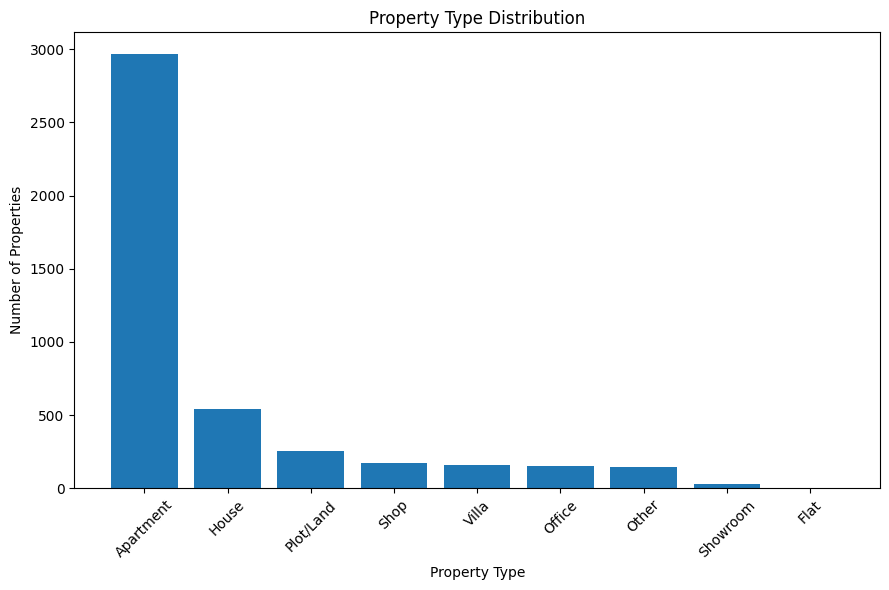

In [68]:
property_counts = df["property_type"].value_counts()
plt.figure(figsize=(9,6))

plt.bar(
    property_counts.index,
     property_counts.values
)

plt.title("Property Type Distribution")
plt.xlabel("Property Type")
plt.ylabel("Number of Properties")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Property Type Distribution.

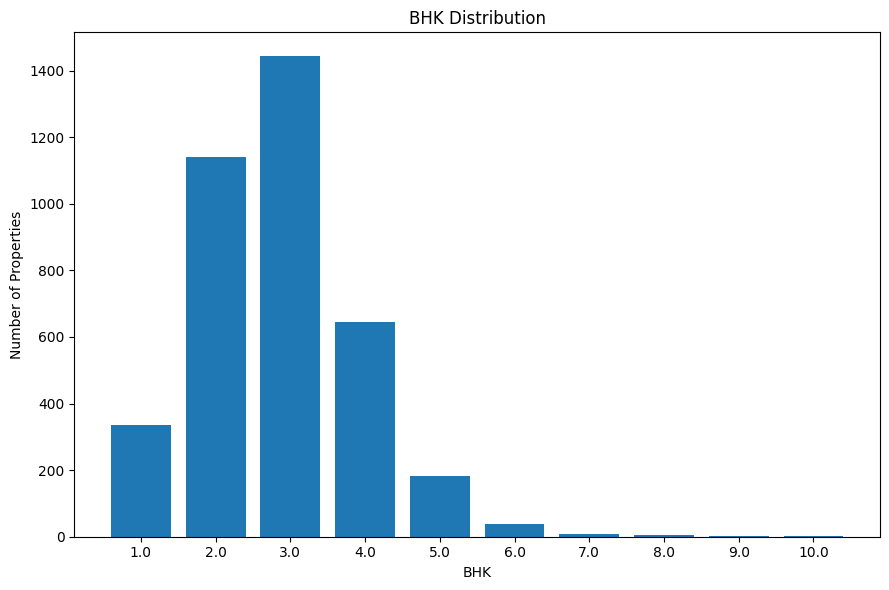

In [69]:
bhk_counts = df["bhk"].dropna().value_counts().sort_index()


plt.figure(figsize=(9, 6))

plt.bar(
    bhk_counts.index.astype(str),
    bhk_counts.values
)

plt.title("BHK Distribution")
plt.xlabel("BHK")
plt.ylabel("Number of Properties")

plt.tight_layout()
plt.show()

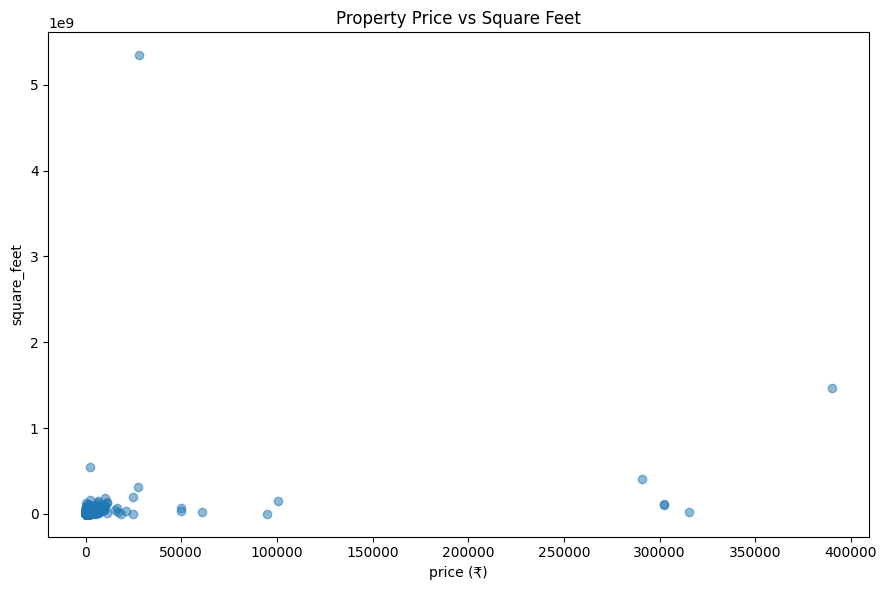

In [74]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df["square_feet"],
    df["price"],
    alpha=0.5
)

plt.title("Property Price vs Square Feet")
plt.xlabel("price (₹)")
plt.ylabel("square_feet")

plt.tight_layout()
plt.show()